In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from src.datasets import MaterialsProject
from pymatgen.core import Structure
import json

In [3]:
mp = MaterialsProject()
mp.load(force_fetch=False)

2026-03-23 13:41:13.280 | INFO     | src.datasets:load:989 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9,"[4.619654, 0.736364, … 0.0]","[0.100292, 0.26796, … 0.0]"
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9,"[5.545048, 0.773538, … 0.0]","[0.100956, 0.268515, … 0.0]"
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9,"[5.775085, 0.776909, … 0.0]","[0.101054, 0.268578, … 0.0]"


In [4]:
mp.df["raw_structure"][0]

'{"@module": "pymatgen.core.structure", "@class": "Structure", "charge": 0, "lattice": {"matrix": [[2.176648, -2.210439, -0.019736], [2.157691, 2.157191999999999, -4.425946], [2.163513, 2.236831, 4.466648]], "pbc": [true, true, true], "a": 3.1022937640270305, "b": 5.375695840657374, "c": 5.443817206669784, "alpha": 110.55665728789754, "beta": 91.09699169817493, "gamma": 89.9466003593816, "volume": 84.98847683834407}, "properties": {}, "sites": [{"species": [{"element": "Fe", "occu": 1}], "abc": [0.5, 0.0, 0.5], "properties": {"magmom": -3.73}, "label": "Fe", "xyz": [2.1700805, 0.013195999999999986, 2.223456]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.0, 0.5, 0.5], "properties": {"magmom": -3.727}, "label": "Fe", "xyz": [2.160602, 2.1970114999999995, 0.02035100000000023]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.0, 0.0, 0.0], "properties": {"magmom": 3.73}, "label": "Fe", "xyz": [0.0, 0.0, 0.0]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.500001, 0.

In [9]:
duplicate_embeddings = mp.df.join(
    mp.df.group_by("soap_embedding")
        .len()
        .filter(pl.col("len") > 1),
    on="soap_embedding"
)

duplicate_embeddings

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding,len
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],u32


# Plots for investegating

In [5]:
def plot_crystal_system_diversity(df: pl.DataFrame):
    """
    Generates a bar plot showing the distribution of crystal systems.
    """
    logger.info("Generating Crystal System distribution plot...")
    
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Fix: Added x as hue and set legend=False to satisfy new Seaborn syntax
    ax = sns.barplot(
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
        hue=crystal_counts["crystal_system"].to_list(),
        palette="magma",
        edgecolor=".2",
        legend=False 
    )

    plt.title("Materials Project: Diversity of Crystal Systems", fontsize=15, fontweight='bold')
    plt.xlabel("Crystal System", fontsize=12)
    plt.ylabel("Count (Number of Materials)", fontsize=12)
    plt.xticks(rotation=45)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/crystal_system_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_volume_distribution(df: pl.DataFrame):
    """
    Generates a KDE plot for Lattice Volume distribution across crystal systems.
    """
    logger.info("Generating Volume Distribution plot...")
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # Fix: Capture the axes object 'ax'
    ax = sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.4,
        palette="viridis"
    )

    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=15, fontweight='bold')
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    
    # Fix: Use sns.move_legend instead of plt.legend()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Crystal System")
    
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/volume_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    logger.success("Visualization complete.")

2026-03-10 16:17:53.953 | INFO     | __main__:plot_crystal_system_diversity:5 - Generating Crystal System distribution plot...


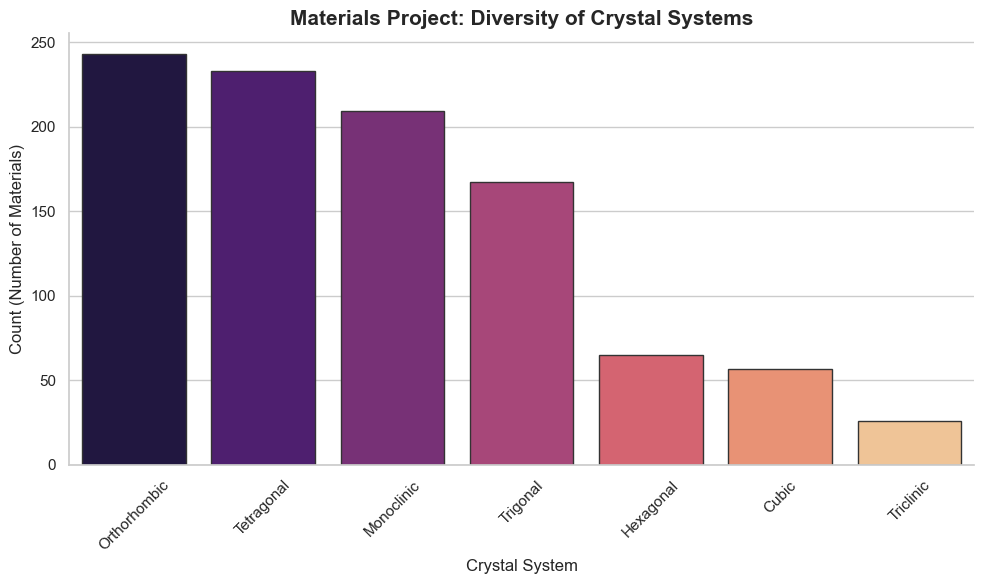

2026-03-10 16:17:54.253 | INFO     | __main__:plot_volume_distribution:40 - Generating Volume Distribution plot...


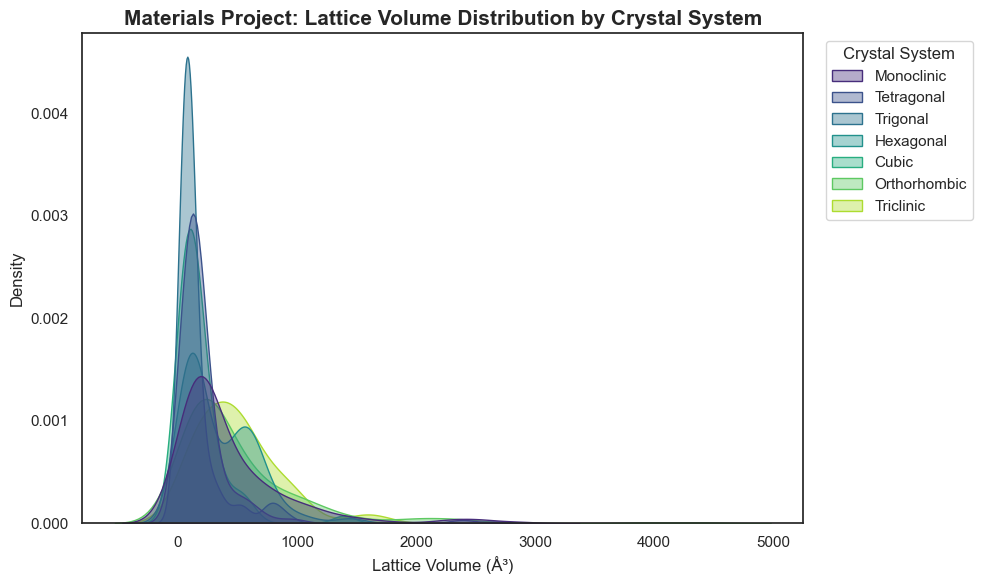

2026-03-10 16:17:54.458 | SUCCESS  | __main__:plot_volume_distribution:66 - Visualization complete.


In [6]:
plot_crystal_system_diversity(mp.df)
plot_volume_distribution(mp.df)

# Show raw structure

In [7]:
mp.df['formula_pretty'][0]

'FeO'

In [13]:
struct_json = mp.df["raw_structure"][0]
struct = Structure.from_dict(json.loads(struct_json))
print(struct)
struct

Full Formula (Fe4 O4)
Reduced Formula: FeO
abc   :   3.102294   5.375696   5.443817
angles: 110.556657  91.096992  89.946600
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Fe    0.5       0         0.5         -3.73
  1  Fe    0         0.5       0.5         -3.727
  2  Fe    0         0         0            3.73
  3  Fe    0.500001  0.5       0            3.727
  4  O     0.968291  0.251676  0.742066    -0.006
  5  O     0.468313  0.251673  0.242068     0.006
  6  O     0.031709  0.748324  0.257934    -0.006
  7  O     0.531686  0.748327  0.757932     0.006


Structure Summary
Lattice
    abc : 3.1022937640270305 5.375695840657374 5.443817206669784
 angles : 110.55665728789754 91.09699169817493 89.9466003593816
 volume : 84.98847683834407
      A : np.float64(2.176648) np.float64(-2.210439) np.float64(-0.019736)
      B : np.float64(2.157691) np.float64(2.157191999999999) np.float64(-4.425946)
      C : np.float64(2.163513) np.float64(2.236831) np.float64(4.466648)
    pbc : True True True
PeriodicSite: Fe (2.17, 0.0132, 2.223) [0.5, 0.0, 0.5]
PeriodicSite: Fe (2.161, 2.197, 0.02035) [0.0, 0.5, 0.5]
PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Fe (2.167, -0.02663, -2.223) [0.5, 0.5, 0.0]
PeriodicSite: O (4.256, 0.06244, 2.182) [0.9683, 0.2517, 0.7421]
PeriodicSite: O (2.086, 0.04919, -0.0419) [0.4683, 0.2517, 0.2421]
PeriodicSite: O (2.242, 2.121, -2.161) [0.03171, 0.7483, 0.2579]
PeriodicSite: O (4.412, 2.134, 0.06287) [0.5317, 0.7483, 0.7579]

In [15]:
from chemiscope import show
from pymatgen.io.ase import AseAtomsAdaptor

adaptor = AseAtomsAdaptor()
atoms = adaptor.get_atoms(struct)
#show(atoms, mode="structure")
atoms_super = atoms.repeat([2,2,2])
show([atoms_super], mode="structure")

<StructureWidget(meta={'name': ' '}, structures=[{'size': 64, 'data': 'structure-0'}], properties={'index': {'…